# Gradient Descent & Stochastic Gradient Descent
### A Hands-On Tutorial for New Students

---

## 1. The Big Idea

Imagine standing on a foggy hill, trying to reach the bottom. You can't see far,
but you can feel the slope beneath your feet. You take a small step downhill,
feel the new slope, and repeat.

That's **gradient descent**:

- The "hill" is a **loss function** $J(\theta)$
- The "slope" is the **gradient** $\nabla J(\theta)$
- The "step size" is the **learning rate** $\alpha$

The **update rule**:

$$
\theta \leftarrow \theta - \alpha \, \nabla_\theta J(\theta)
$$

Repeat until the loss stops decreasing (convergence).

---

## 2. Why It Works — The Gradient

The gradient is the vector of **partial derivatives** of the loss
with respect to each parameter. For $\theta = (\theta_1, \theta_2, \dots, \theta_n)$:

$$
\nabla_\theta J(\theta) =
\begin{bmatrix}
\dfrac{\partial J}{\partial \theta_1} \\[6pt]
\dfrac{\partial J}{\partial \theta_2} \\[6pt]
\vdots \\[4pt]
\dfrac{\partial J}{\partial \theta_n}
\end{bmatrix}
$$

The gradient points in the direction of **steepest ascent**. Moving in the
opposite direction (subtracting it) guarantees — for a small enough
$\alpha$ — that the loss decreases:

$$
J(\theta - \alpha \nabla_\theta J) \approx J(\theta) - \alpha \|\nabla_\theta J\|^2
$$

The right-hand side is **less than** $J(\theta)$ whenever $\alpha > 0$ and
$\nabla_\theta J \neq 0$.

---

## 3. Our Concrete Problem

We'll fit a line $y = wx + b$ to noisy data using **Mean Squared Error**:

$$
J(w, b) = \frac{1}{N} \sum_{i=1}^{N} \bigl(y_i - (w x_i + b)\bigr)^2
$$

Its gradients (derived with the chain rule) are:

$$
\frac{\partial J}{\partial w} = -\frac{2}{N}\sum_{i=1}^{N} x_i \bigl(y_i - \hat{y}_i\bigr),
\qquad
\frac{\partial J}{\partial b} = -\frac{2}{N}\sum_{i=1}^{N} \bigl(y_i - \hat{y}_i\bigr)
$$

where $\hat{y}_i = w x_i + b$.

---

## 4. The Three Flavors

| Method | Uses per update | Pros | Cons |
|---|---|---|---|
| **Batch GD** | All $N$ samples | Smooth, exact gradient | Slow for large $N$ |
| **SGD** | 1 sample | Very fast per update | Noisy path |
| **Mini-batch GD** | $B$ samples (e.g. 32) | Balanced | Needs tuning $B$ |

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# Reproducibility
np.random.seed(42)

# Nicer plots
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Libraries loaded.")

Libraries loaded.


## 5. Visualizing the Concept — A 1D Loss Landscape

Before fitting a real model, let's build intuition. Consider a simple
quadratic loss:

$$
J(\theta) = (\theta - 3)^2 + 2
$$

Its derivative is $\dfrac{dJ}{d\theta} = 2(\theta - 3)$, so we can watch a
ball roll down the parabola following the rule
$\theta \leftarrow \theta - \alpha \cdot 2(\theta - 3)$.

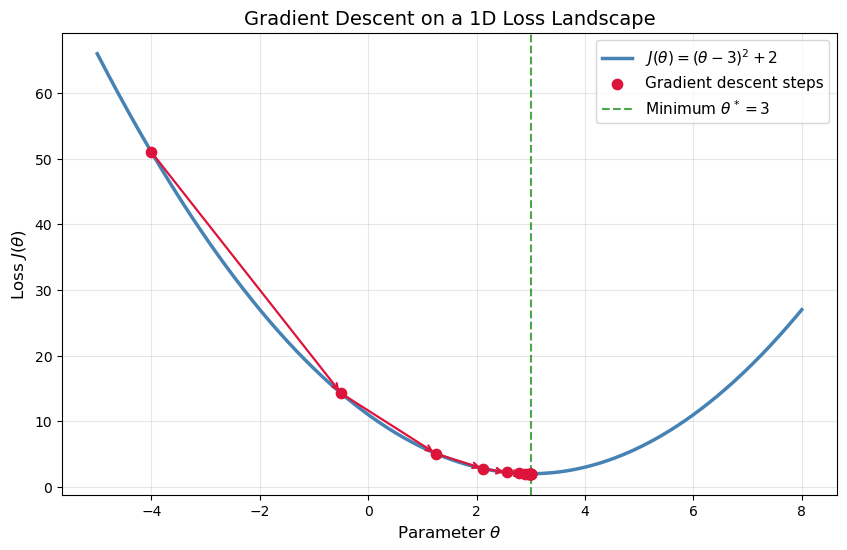

In [3]:
# Define the loss and its gradient
def J(theta):
    return (theta - 3)**2 + 2

def dJ(theta):
    return 2 * (theta - 3)

# Gradient descent run
theta = -4.0
alpha = 0.25
path = [theta]
for _ in range(15):
    theta = theta - alpha * dJ(theta)
    path.append(theta)
path = np.array(path)

# Plot the loss curve and the descent steps
t = np.linspace(-5, 8, 400)
plt.figure(figsize=(10, 6))
plt.plot(t, J(t), color="steelblue", linewidth=2.5, label=r"$J(\theta)=(\theta-3)^2+2$")

plt.scatter(path, J(path), color="crimson", zorder=5, s=55,
            label="Gradient descent steps")
for i in range(len(path) - 1):
    plt.annotate("", xy=(path[i+1], J(path[i+1])),
                 xytext=(path[i], J(path[i])),
                 arrowprops=dict(arrowstyle="->", color="crimson", lw=1.6))

plt.axvline(3, color="green", linestyle="--", alpha=0.7, label=r"Minimum $\theta^*=3$")

plt.title("Gradient Descent on a 1D Loss Landscape", fontsize=14)
plt.xlabel(r"Parameter $\theta$", fontsize=12)
plt.ylabel(r"Loss $J(\theta)$", fontsize=12)
plt.legend(fontsize=11)
plt.show()

## 6. Animating the Descent

A short animation makes the "rolling downhill" idea click.

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t, J(t), color="steelblue", linewidth=2.5)
ax.set_xlim(-5, 8)
ax.set_ylim(0, J(-5) + 5)
ax.set_xlabel(r"Parameter $\theta$", fontsize=12)
ax.set_ylabel(r"Loss $J(\theta)$", fontsize=12)
ax.set_title("Animated Gradient Descent", fontsize=14)

line, = ax.plot([], [], "o-", color="crimson", lw=1.5, markersize=8)
txt = ax.text(0.02, 0.95, "", transform=ax.transAxes, fontsize=11,
              verticalalignment="top",
              bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))

def init():
    line.set_data([], [])
    txt.set_text("")
    return line, txt

def update(i):
    line.set_data(path[:i+1], J(path[:i+1]))
    txt.set_text(f"step {i}   θ = {path[i]:.3f}   J = {J(path[i]):.3f}")
    return line, txt

anim = FuncAnimation(fig, update, frames=len(path),
                     init_func=init, interval=350, blit=True)

plt.close(fig)
HTML(anim.to_jshtml())

## 7. Generating Synthetic Data

We'll fit $y = 3x + 2$ with Gaussian noise added.

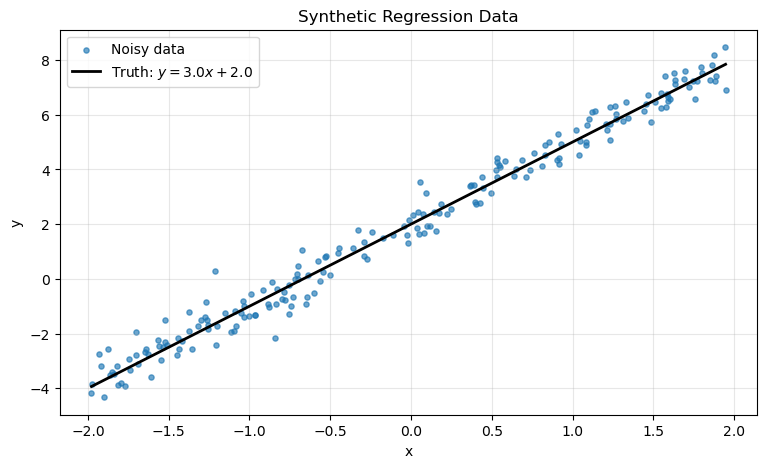

In [5]:
N = 200
X = np.random.uniform(-2, 2, size=N)
true_w, true_b = 3.0, 2.0
y = true_w * X + true_b + np.random.normal(0, 0.5, size=N)

plt.figure(figsize=(9, 5))
plt.scatter(X, y, s=14, alpha=0.65, label="Noisy data")
plt.plot(np.sort(X), true_w*np.sort(X) + true_b, color="black",
         linewidth=2, label=rf"Truth: $y = {true_w}x + {true_b}$")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Synthetic Regression Data")
plt.legend()
plt.show()

## 8. Batch Gradient Descent

Uses **all $N$ samples** per update. The gradient is exact:

$$
\nabla J(w, b) = \left(-\frac{2}{N}\sum_i x_i(y_i - \hat{y}_i),\;
                  -\frac{2}{N}\sum_i (y_i - \hat{y}_i)\right)
$$

In [6]:
def compute_gradients(X, y, w, b):
    """Gradients of MSE loss w.r.t. w and b (batch)."""
    N = len(y)
    y_pred = w * X + b
    err = y_pred - y
    dw = (2 / N) * np.sum(err * X)
    db = (2 / N) * np.sum(err)
    return dw, db

def batch_gradient_descent(X, y, lr=0.1, epochs=100):
    w, b = 0.0, 0.0
    losses = []
    for _ in range(epochs):
        dw, db = compute_gradients(X, y, w, b)
        w -= lr * dw
        b -= lr * db
        losses.append(np.mean((w*X + b - y) ** 2))
    return w, b, losses

w_gd, b_gd, losses_gd = batch_gradient_descent(X, y, lr=0.1, epochs=100)
print(f"Batch GD  ->  w = {w_gd:.3f},  b = {b_gd:.3f}")
print(f"Final loss = {losses_gd[-1]:.5f}")

Batch GD  ->  w = 2.990,  b = 2.033
Final loss = 0.23346


## 9. Stochastic Gradient Descent (SGD)

Uses **one sample** per update. The gradient estimate is noisy but cheap:

$$
\nabla J_i(w, b) = \bigl(-2 x_i (y_i - \hat{y}_i),\;
                        -2(y_i - \hat{y}_i)\bigr)
$$

Shuffling the data every epoch is **essential** — otherwise the model
will learn patterns from the order of the samples.

In [7]:
def stochastic_gradient_descent(X, y, lr=0.01, epochs=20):
    w, b = 0.0, 0.0
    losses = []
    N = len(y)
    for _ in range(epochs):
        for i in np.random.permutation(N):
            xi, yi = X[i], y[i]
            err = (w * xi + b) - yi
            w -= lr * 2 * err * xi
            b -= lr * 2 * err
        losses.append(np.mean((w*X + b - y) ** 2))
    return w, b, losses

w_sgd, b_sgd, losses_sgd = stochastic_gradient_descent(X, y, lr=0.01, epochs=20)
print(f"SGD       ->  w = {w_sgd:.3f},  b = {b_sgd:.3f}")
print(f"Final loss = {losses_sgd[-1]:.5f}")

SGD       ->  w = 3.000,  b = 2.081
Final loss = 0.23585


## 10. Mini-Batch Gradient Descent

The **practical sweet spot**. Uses $B$ samples per update:

$$
\nabla J_B(w, b) = \left(-\frac{2}{B}\sum_{i \in B} x_i(y_i - \hat{y}_i),\;
                       -\frac{2}{B}\sum_{i \in B} (y_i - \hat{y}_i)\right)
$$

In [8]:
def minibatch_gradient_descent(X, y, lr=0.05, epochs=50, batch_size=16):
    w, b = 0.0, 0.0
    losses = []
    N = len(y)
    for _ in range(epochs):
        idx = np.random.permutation(N)
        Xs, ys = X[idx], y[idx]
        for start in range(0, N, batch_size):
            xb = Xs[start:start + batch_size]
            yb = ys[start:start + batch_size]
            m = len(yb)
            err = (w * xb + b) - yb
            w -= lr * (2 / m) * np.sum(err * xb)
            b -= lr * (2 / m) * np.sum(err)
        losses.append(np.mean((w*X + b - y) ** 2))
    return w, b, losses

w_mb, b_mb, losses_mb = minibatch_gradient_descent(X, y, lr=0.05,
                                                    epochs=50, batch_size=16)
print(f"Mini-batch ->  w = {w_mb:.3f},  b = {b_mb:.3f}")
print(f"Final loss = {losses_mb[-1]:.5f}")

Mini-batch ->  w = 3.034,  b = 2.036
Final loss = 0.23609


## 11. Comparing the Three Methods

| Method | Update cost | Gradient variance | Convergence |
|---|---|---|---|
| Batch GD | $O(N)$ | None | Smooth |
| SGD | $O(1)$ | High | Noisy |
| Mini-batch | $O(B)$ | Medium | Balanced |

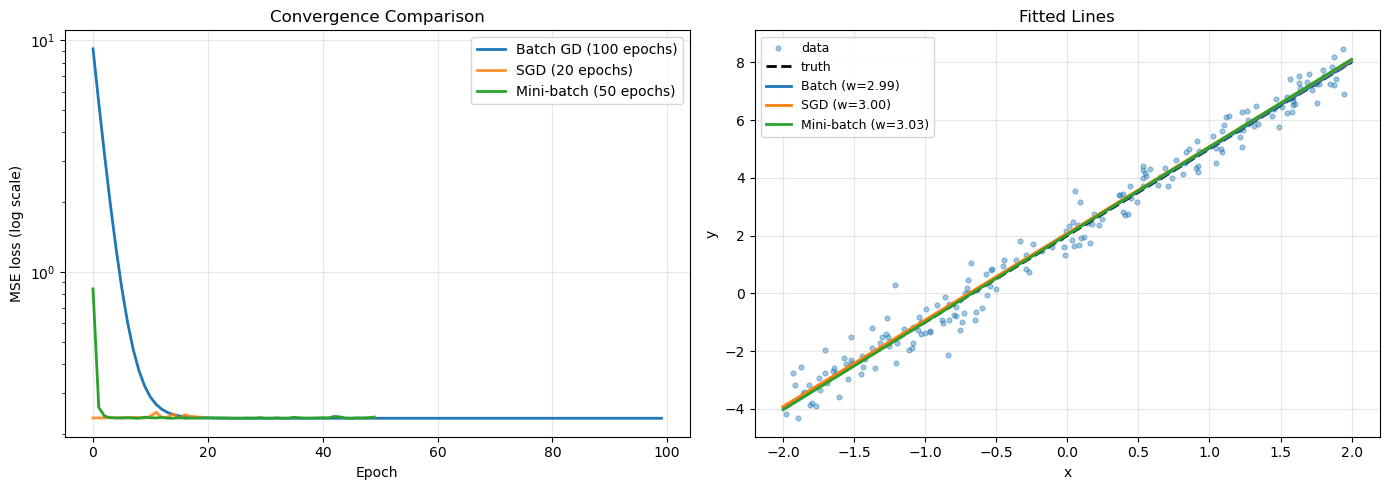

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: loss curves
ax = axes[0]
ax.plot(losses_gd, label="Batch GD (100 epochs)", lw=2)
ax.plot(losses_sgd, label="SGD (20 epochs)", lw=2, alpha=0.85)
ax.plot(losses_mb, label="Mini-batch (50 epochs)", lw=2)
ax.set_yscale("log")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE loss (log scale)")
ax.set_title("Convergence Comparison")
ax.legend()

# Right: fitted lines
ax = axes[1]
xs = np.linspace(-2, 2, 100)
ax.scatter(X, y, s=12, alpha=0.4, label="data")
ax.plot(xs, true_w*xs + true_b, "k--", lw=2, label="truth")
ax.plot(xs, w_gd*xs + b_gd, lw=2, label=f"Batch (w={w_gd:.2f})")
ax.plot(xs, w_sgd*xs + b_sgd, lw=2, label=f"SGD (w={w_sgd:.2f})")
ax.plot(xs, w_mb*xs + b_mb, lw=2, label=f"Mini-batch (w={w_mb:.2f})")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Fitted Lines")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 12. Learning Rate Sensitivity

The learning rate $\alpha$ is the single most important hyperparameter.

- **Too small** → painfully slow convergence.
- **Just right** → smooth descent to the minimum.
- **Too large** → divergence (loss explodes to `inf` or `nan`).

$$
\theta_{t+1} = \theta_t - \alpha \nabla J(\theta_t)
$$

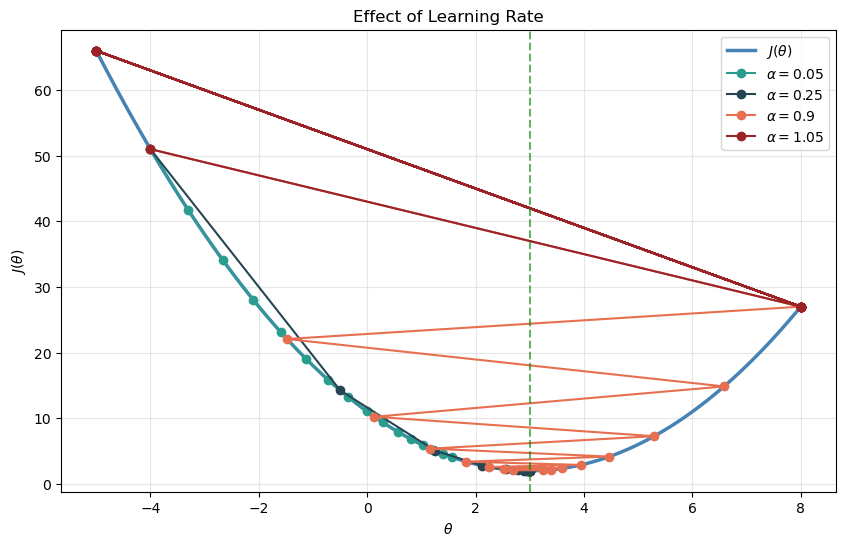

In [10]:
def run_gd(theta0, alpha, steps=15):
    theta, path = theta0, [theta0]
    for _ in range(steps):
        theta = theta - alpha * dJ(theta)
        path.append(theta)
    return np.array(path)

alphas = [0.05, 0.25, 0.9, 1.05]
colors = ["#2a9d8f", "#264653", "#e76f51", "#9b2226"]

plt.figure(figsize=(10, 6))
plt.plot(t, J(t), color="steelblue", lw=2.5, label=r"$J(\theta)$")

for a, c in zip(alphas, colors):
    p = run_gd(-4.0, a)
    p_vis = np.clip(p, -5, 8)
    plt.plot(p_vis, J(p_vis), "o-", color=c, lw=1.5, markersize=6,
             label=rf"$\alpha={a}$")

plt.axvline(3, color="green", ls="--", alpha=0.6)
plt.title("Effect of Learning Rate")
plt.xlabel(r"$\theta$"); plt.ylabel(r"$J(\theta)$")
plt.legend()
plt.show()

## 13. Common Pitfalls for Beginners

1. **Forgetting to shuffle** in SGD — the model learns from sample order.
2. **Not normalizing features** — gradients blow up; always standardize.
3. **Learning rate too high** — `nan` losses are the tell-tale symptom.
4. **Confusing epoch with iteration**
   - *Epoch*: one full pass through the dataset
   - *Iteration*: one parameter update
5. **Averaging loss incorrectly** — compute epoch-level loss on the
   whole dataset for a clean curve.

---

## 14. Where to Go Next

| Concept | Purpose |
|---|---|
| Momentum | Accumulate velocity to smooth updates |
| Nesterov | Look ahead before computing gradient |
| Adagrad | Per-parameter adaptive learning rates |
| RMSProp | Fix Adagrad's decaying rate |
| **Adam** | Momentum + RMSProp (industry default) |

In PyTorch these are one-liners:

```python
optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
optim.Adam(model.parameters(), lr=1e-3)
```

---

## 15. TL;DR

- Gradient descent walks downhill using $\theta \leftarrow \theta - \alpha \nabla J(\theta)$.
- **Batch GD**: exact gradient, slow. **SGD**: noisy gradient, fast.
  **Mini-batch**: the practical middle ground used everywhere.
- Always shuffle, watch your learning rate, and remember: *small steps,
  many times, downhill*.